**Decision Tree Machine Learning - Beginner Friendly Notebook**

# =========================================
# 1. What is a Decision Tree?
# =========================================
# A Decision Tree is a supervised learning algorithm used for classification and regression.
# It works like a flowchart:
#   - Each internal node = a decision based on a feature
#   - Each branch = outcome of the decision
#   - Each leaf node = final prediction

# Example:
# If Temperature > 80 -> Check Load Cycles
# Else -> Safe Operation


# =========================================
# 2. Real-World Example: Mechanical Maintenance
# =========================================
# Goal: Predict maintenance priority
#
# Input Features:
# - Usage Hours
# - Load Cycles
# - Temperature
#
# Output Labels:
# - "Immediate Maintenance"
# - "Monitor Closely"
# - "Safe Operation"


In [3]:
# =========================================
# 3. Create Sample Dataset
# =========================================
import pandas as pd

# Sample data

data = {
    'usage_hours': [100, 500, 300, 800, 200, 600, 700, 150, 400, 900],
    'load_cycles': [10, 50, 30, 80, 20, 60, 70, 15, 40, 90],
    'temperature': [40, 85, 60, 95, 50, 88, 92, 45, 70, 100],
    'status': [
        'Safe Operation',
        'Immediate Maintenance',
        'Monitor Closely',
        'Immediate Maintenance',
        'Safe Operation',
        'Immediate Maintenance',
        'Immediate Maintenance',
        'Safe Operation',
        'Monitor Closely',
        'Immediate Maintenance'
    ]
}

df = pd.DataFrame(data)
print(df)

   usage_hours  load_cycles  temperature                 status
0          100           10           40         Safe Operation
1          500           50           85  Immediate Maintenance
2          300           30           60        Monitor Closely
3          800           80           95  Immediate Maintenance
4          200           20           50         Safe Operation
5          600           60           88  Immediate Maintenance
6          700           70           92  Immediate Maintenance
7          150           15           45         Safe Operation
8          400           40           70        Monitor Closely
9          900           90          100  Immediate Maintenance


In [4]:
# =========================================
# 4. Encode Labels
# =========================================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['status_encoded'] = le.fit_transform(df['status'])

print("\nEncoded Labels:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


Encoded Labels:
{'Immediate Maintenance': np.int64(0), 'Monitor Closely': np.int64(1), 'Safe Operation': np.int64(2)}


In [5]:
# =========================================
# 5. Split Features and Target
# =========================================
X = df[['usage_hours', 'load_cycles', 'temperature']]
y = df['status_encoded']

In [6]:
# =========================================
# 6. Train Decision Tree Model
# =========================================
from sklearn.tree import DecisionTreeClassifier

# Pre-Pruning using constraints
model = DecisionTreeClassifier(
    max_depth=3,           # Limits tree depth (pre-pruning)
    min_samples_split=2,   # Minimum samples to split
    min_samples_leaf=1,    # Minimum samples per leaf
    random_state=42
)

model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [7]:
# =========================================
# 7. Make Predictions
# =========================================
predictions = model.predict(X)

# Convert back to labels
predicted_labels = le.inverse_transform(predictions)

print("\nPredictions:")
for i in range(len(X)):
    print(X.iloc[i].to_dict(), "->", predicted_labels[i])


Predictions:
{'usage_hours': 100, 'load_cycles': 10, 'temperature': 40} -> Safe Operation
{'usage_hours': 500, 'load_cycles': 50, 'temperature': 85} -> Immediate Maintenance
{'usage_hours': 300, 'load_cycles': 30, 'temperature': 60} -> Monitor Closely
{'usage_hours': 800, 'load_cycles': 80, 'temperature': 95} -> Immediate Maintenance
{'usage_hours': 200, 'load_cycles': 20, 'temperature': 50} -> Safe Operation
{'usage_hours': 600, 'load_cycles': 60, 'temperature': 88} -> Immediate Maintenance
{'usage_hours': 700, 'load_cycles': 70, 'temperature': 92} -> Immediate Maintenance
{'usage_hours': 150, 'load_cycles': 15, 'temperature': 45} -> Safe Operation
{'usage_hours': 400, 'load_cycles': 40, 'temperature': 70} -> Monitor Closely
{'usage_hours': 900, 'load_cycles': 90, 'temperature': 100} -> Immediate Maintenance


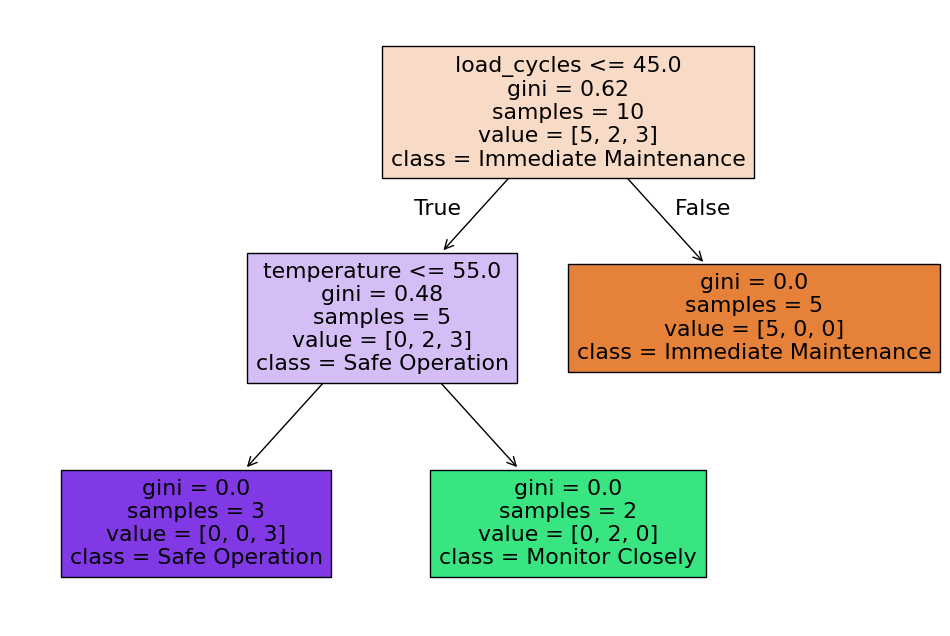

In [7]:
# =========================================
# 8. Visualize Decision Tree
# =========================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=le.classes_, filled=True)
plt.show()

# =========================================
# 9. Understanding Overfitting
# =========================================
# Overfitting happens when the tree learns noise instead of pattern.
# Example: very deep tree memorizes training data.
#
# Solution:
# - Pre-Pruning (used above): max_depth, min_samples_leaf
# - Post-Pruning: remove unnecessary branches after training

In [8]:
# =========================================
# 10. Post-Pruning Example
# =========================================
# Cost Complexity Pruning
path = model.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas

models = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X, y)
    models.append(clf)

print("\nNumber of pruned models:", len(models))


Number of pruned models: 3


# =========================================
# 11. Key Concepts Summary
# =========================================
# - Decision Tree splits data based on feature thresholds
# - Overfitting = too complex tree
# - Pre-Pruning = control tree growth early
# - Post-Pruning = trim tree after training
# - Minimal Tree Length = smallest tree that generalizes well

In [9]:
# =========================================
# 12. Try New Prediction
# =========================================
new_data = pd.DataFrame({
    'usage_hours': [650],
    'load_cycles': [65],
    'temperature': [90]
})

pred = model.predict(new_data)
print("\nNew Prediction:", le.inverse_transform(pred)[0])


New Prediction: Immediate Maintenance
